# DeepLoc 2.1 on COSMIC Cancer Mutation Census (CMC): subcellular localization variant effects

Loads the merged wild-type vs. mutant DeepLoc 2.1 predictions (`cmc_deeploc_deltas_rbp.tsv`, built by `../12_variant_effect_prediction/localization_condensate/merge_deeploc_deltas.py`) and does a sanity check plus first-pass exploration.

**Data file is not checked into git** (~1.6GB). Regenerate it with the pipeline in `12_variant_effect_prediction/`, or pull it from `/u/project/kappel/ddcohn/protein_variant_effects/` on Hoffman2.

**How the numbers were made.** Each variant's protein-level mutant sequence was built from the wild-type protein and scored with DeepLoc 2.1 (ESM1b), the same as the wild-type protein. `DELTA_x = MUT_x - WT_x` for each of 10 compartment probabilities and 4 membrane-type probabilities. `WT_label`/`MUT_label` are DeepLoc's predicted (multi-label) localization strings; `label_changed` is 1 if they differ. Only missense, nonsense, and in-frame indel-type variants are included (frameshift and stop-loss variants need CDS-level handling and are not built yet).

**RBP-only version.** Filtered to the 2,215-gene RNA-binding-protein list in `../12_variant_effect_prediction/rbp_filter/rbp_gene_symbols.txt` (union of a classic-RNA-binding-domain list and RBP2GO's high-confidence human RBP dataset -- see that folder's README for the full method). The genome-wide version of this notebook is `deeploc_cmc_exploration.ipynb`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
PALETTE = ["#8ecae6", "#219ebc", "#023047", "#ffb703", "#fb8500"]
sns.set_palette(PALETTE)

LOCS = ["Cytoplasm", "Nucleus", "Extracellular", "Cell membrane", "Mitochondrion", "Plastid",
        "Endoplasmic reticulum", "Lysosome/Vacuole", "Golgi apparatus", "Peroxisome"]
MEMB = ["Peripheral", "Transmembrane", "Lipid anchor", "Soluble"]
GENE, ID = "GENE_NAME", "GENOMIC_MUTATION_ID"


## Load data

In [2]:
df = pd.read_csv("cmc_deeploc_deltas_rbp.tsv", sep="\t")
print(f"{len(df):,} variant rows, {df[GENE].nunique():,} genes")
df.head()

381,249 variant rows, 1,549 genes


,GENOMIC_MUTATION_ID,GENE_NAME,accession,category,WT_label,MUT_label,label_changed,WT_Cytoplasm,WT_Nucleus,WT_Extracellular,...,DELTA_Mitochondrion,DELTA_Plastid,DELTA_Endoplasmic reticulum,DELTA_Lysosome/Vacuole,DELTA_Golgi apparatus,DELTA_Peroxisome,DELTA_Peripheral,DELTA_Transmembrane,DELTA_Lipid anchor,DELTA_Soluble
0,COSV51273354,EPHA8,ENST00000166244,missense,Cell membrane|Lysosome/Vacuole,Cell membrane|Lysosome/Vacuole,0,0.1541,0.1106,0.1842,...,-0.0004,0.0001,-0.0004,0.0010,-0.0013,0.0003,-0.0004,0.0000,-0.0002,-0.0002
1,COSV51266607,EPHA8,ENST00000166244,missense,Cell membrane|Lysosome/Vacuole,Cell membrane|Lysosome/Vacuole,0,0.1541,0.1106,0.1842,...,0.0001,0.0000,0.0003,-0.0003,-0.0005,0.0001,0.0000,0.0000,-0.0002,0.0002
2,COSV51293908,EPHA8,ENST00000166244,missense,Cell membrane|Lysosome/Vacuole,Cell membrane|Lysosome/Vacuole,0,0.1541,0.1106,0.1842,...,0.0002,0.0000,0.0013,-0.0019,-0.0006,-0.0004,-0.0001,0.0000,-0.0001,-0.0001
3,COSV51268352,EPHA8,ENST00000166244,missense,Cell membrane|Lysosome/Vacuole,Cell membrane|Lysosome/Vacuole,0,0.1541,0.1106,0.1842,...,0.0000,0.0000,0.0009,0.0013,-0.0005,0.0000,0.0003,-0.0001,0.0001,0.0002
4,COSV51278691,EPHA8,ENST00000166244,missense,Cell membrane|Lysosome/Vacuole,Cell membrane|Lysosome/Vacuole,0,0.1541,0.1106,0.1842,...,0.0001,0.0001,0.0001,0.0008,0.0002,0.0000,-0.0001,0.0000,-0.0006,0.0002


## Sanity check: well-known proteins (wild-type predicted localization)

Textbook localizations compared with the top wild-type probability. Mismatches are model behavior to keep in mind, not necessarily pipeline errors.

In [3]:
expected = {"TARDBP": "Nucleus", "MATR3": "Nucleus", "FUS": "Nucleus", "SRSF1": "Nucleus",
            "HNRNPA1": "Nucleus", "PABPC1": "Cytoplasm", "ELAVL1": "Nucleus",
            "G3BP1": "Cytoplasm", "DDX3X": "Cytoplasm"}
wt_cols = [f"WT_{c}" for c in LOCS]
for g, exp in expected.items():
    rows = df[df[GENE] == g]
    if rows.empty:
        print(f"{g:8s}: not in this table"); continue
    r = rows.iloc[0]
    top = r[wt_cols].astype(float).idxmax().replace("WT_", "")
    print(f"{g:8s} top={top:22s} labels={r['WT_label']:35s} expected={exp:15s} [{'OK' if top == exp or exp in r['WT_label'] else 'MISMATCH'}]")

TARDBP   top=Nucleus                labels=Nucleus                             expected=Nucleus         [OK]
MATR3    top=Nucleus                labels=Nucleus                             expected=Nucleus         [OK]
FUS      top=Nucleus                labels=Cytoplasm|Nucleus                   expected=Nucleus         [OK]
SRSF1    top=Nucleus                labels=Cytoplasm|Nucleus                   expected=Nucleus         [OK]
HNRNPA1  top=Nucleus                labels=Cytoplasm|Nucleus                   expected=Nucleus         [OK]
PABPC1   top=Cytoplasm              labels=Cytoplasm|Nucleus                   expected=Cytoplasm       [OK]
ELAVL1   top=Nucleus                labels=Cytoplasm|Nucleus                   expected=Nucleus         [OK]
G3BP1    top=Nucleus                labels=Cytoplasm|Nucleus                   expected=Cytoplasm       [OK]
DDX3X    top=Nucleus                labels=Cytoplasm|Nucleus                   expected=Cytoplasm       [OK]


## Wild-type predicted localization labels (unique protein-transcript pairs)

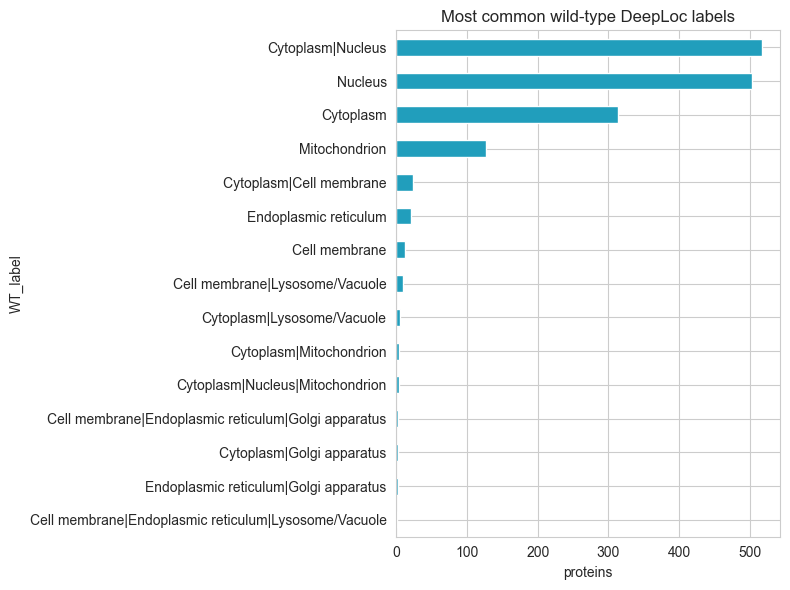

In [4]:
wt = df.drop_duplicates("accession")
top = wt["WT_label"].value_counts().head(15)
top.iloc[::-1].plot.barh(figsize=(8, 6), color="#219ebc")
plt.xlabel("proteins"); plt.title("Most common wild-type DeepLoc labels"); plt.tight_layout(); plt.show()

## How often does a variant change the predicted label?

In [5]:
print(f"Overall label_changed rate: {df['label_changed'].mean():.2%}")
by_cat = df.groupby("category")["label_changed"].agg(["mean", "size"]).sort_values("mean", ascending=False)
by_cat.rename(columns={"mean": "frac_label_changed", "size": "n"})

Overall label_changed rate: 4.05%


,frac_label_changed,n
category,,
nonsense,0.361086,27373
ins,0.031175,417
del,0.024038,2912
delins,0.018970,369
dup,0.015936,502
missense,0.015566,349676


## How many variants change predicted localization?

Counts, then the fraction with a changed label broken down by variant category (missense, nonsense, etc.).

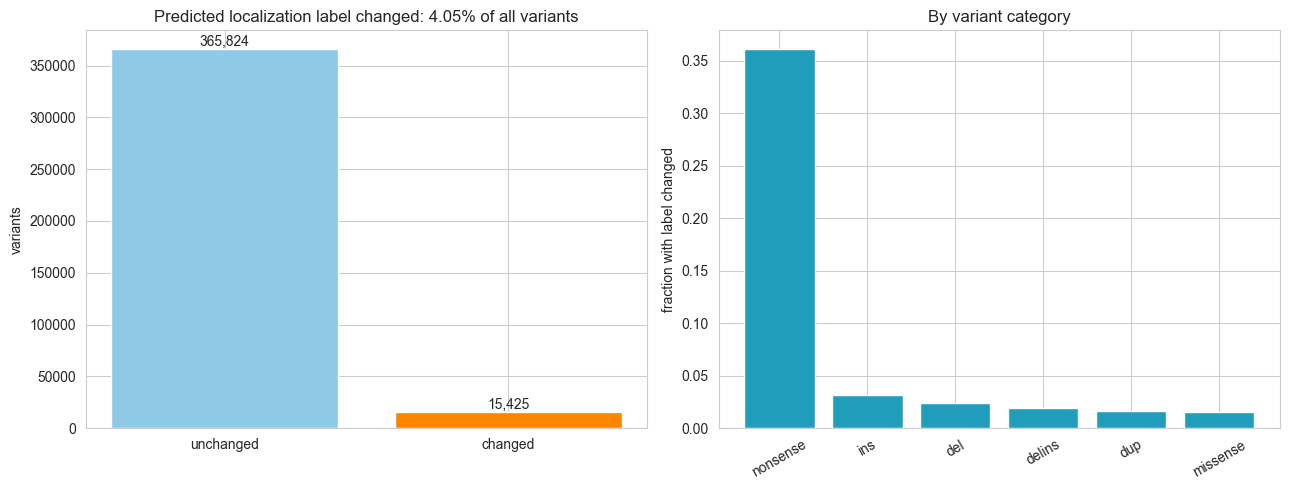

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

counts = df["label_changed"].map({0: "unchanged", 1: "changed"}).value_counts()
axes[0].bar(counts.index, counts.values, color=[PALETTE[0], PALETTE[4]])
axes[0].set_ylabel("variants")
axes[0].set_title(f"Predicted localization label changed: {df['label_changed'].mean():.2%} of all variants")
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")

by_cat = df.groupby("category")["label_changed"].mean().sort_values(ascending=False)
axes[1].bar(by_cat.index, by_cat.values, color=PALETTE[1])
axes[1].set_ylabel("fraction with label changed")
axes[1].set_title("By variant category")
axes[1].tick_params(axis="x", rotation=30)

fig.tight_layout()
plt.show()

## Variant effect (delta) distributions

`DELTA = mutant - WT` probability. Most variants should sit near zero; the tails are the interesting cases (log y-axis).

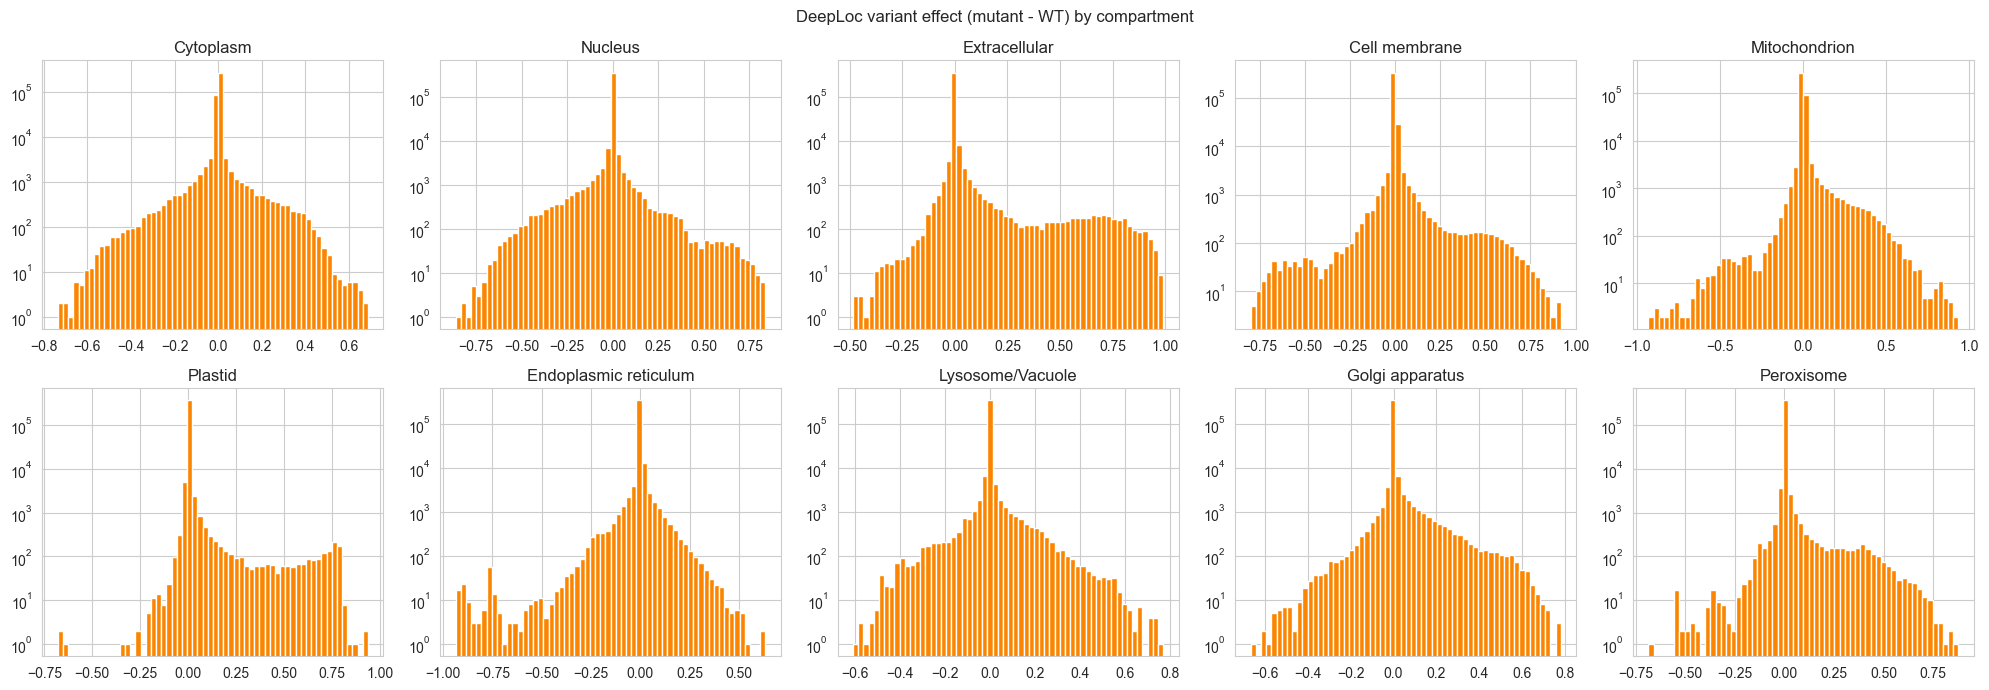

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for ax, c in zip(axes.flat, LOCS):
    ax.hist(df[f"DELTA_{c}"], bins=60, color="#fb8500"); ax.set_yscale("log"); ax.set_title(c)
fig.suptitle("DeepLoc variant effect (mutant - WT) by compartment"); fig.tight_layout(); plt.show()

## Wild-type label to mutant label transitions

Among variants whose label changed: the most common transitions.

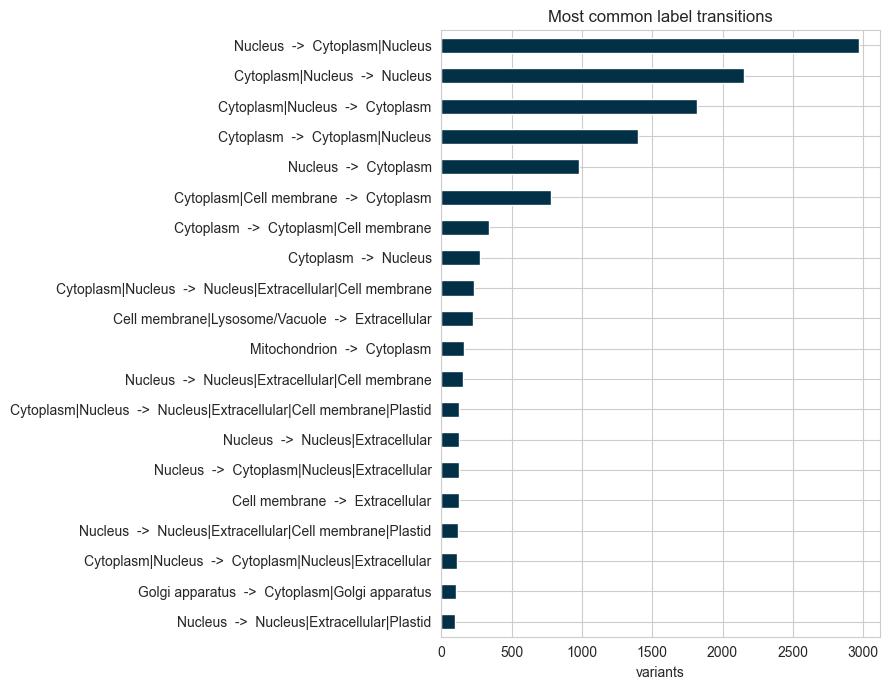

In [8]:
ch = df[df["label_changed"] == 1]
trans = (ch["WT_label"] + "  ->  " + ch["MUT_label"]).value_counts().head(20)
trans.iloc[::-1].plot.barh(figsize=(9, 7), color="#023047")
plt.xlabel("variants"); plt.title("Most common label transitions"); plt.tight_layout(); plt.show()

## Variants with the largest predicted localization shift

Ranked by the largest absolute delta across the 10 compartments.

In [9]:
dcols = [f"DELTA_{c}" for c in LOCS]
mx = df[dcols].abs().max(axis=1)
top = df.loc[mx.sort_values(ascending=False).index[:25]]
top[[ID, GENE, "category", "WT_label", "MUT_label"] + dcols]

,GENOMIC_MUTATION_ID,GENE_NAME,category,WT_label,MUT_label,DELTA_Cytoplasm,DELTA_Nucleus,DELTA_Extracellular,DELTA_Cell membrane,DELTA_Mitochondrion,DELTA_Plastid,DELTA_Endoplasmic reticulum,DELTA_Lysosome/Vacuole,DELTA_Golgi apparatus,DELTA_Peroxisome
268953,COSV68304827,PLAA,missense,Cytoplasm|Nucleus,Cytoplasm|Nucleus|Extracellular|Cell membrane|...,-0.1624,0.2818,0.9907,0.4616,0.0781,0.3580,0.0769,-0.2765,0.2543,0.1976
268969,COSV68305825,PLAA,missense,Cytoplasm|Nucleus,Nucleus|Extracellular|Plastid,-0.4611,0.3749,0.9895,0.2250,0.0148,0.7729,-0.2306,-0.3739,-0.0268,-0.0035
214514,COSV55746529,STRN,nonsense,Cytoplasm|Nucleus,Nucleus|Extracellular|Plastid,-0.2689,0.3151,0.9769,0.3370,0.2385,0.7663,-0.1414,-0.2277,0.3019,0.1381
215578,COSV113408250,MRPS25,missense,Mitochondrion,Cytoplasm|Nucleus|Extracellular,0.1332,0.6925,0.9761,0.0824,-0.9330,0.4371,-0.0127,-0.0435,0.1921,0.0508
221443,COSV55722208,PPP6R3,missense,Cytoplasm|Nucleus,Nucleus|Extracellular|Plastid,-0.5521,0.3196,0.9720,-0.0355,0.1413,0.8122,-0.1363,-0.1309,-0.0529,0.0059
268995,COSV101263583,PLAA,missense,Cytoplasm|Nucleus,Nucleus|Extracellular|Cell membrane|Plastid|Go...,-0.3759,0.1927,0.9709,0.5261,0.2249,0.7528,0.2266,-0.2520,0.3117,0.6271
269114,COSV68304816,PLAA,missense,Cytoplasm|Nucleus,Cytoplasm|Nucleus|Extracellular|Golgi apparatus,-0.1251,0.4073,0.9680,0.1430,-0.0091,0.0257,-0.1845,-0.3576,0.3043,-0.0062
259407,COSV105298765,NKAP,missense,Nucleus,Nucleus|Extracellular|Plastid,0.1571,-0.0407,0.9667,0.3298,0.4541,0.7607,0.0281,-0.0333,0.4703,0.1006
259361,COSV107472549,NKAP,missense,Nucleus,Nucleus|Extracellular|Plastid,0.1255,-0.0885,0.9663,0.2662,0.3654,0.7577,0.0219,-0.0329,0.5846,0.1568
212550,COSV53704055,CSE1L,missense,Cytoplasm|Nucleus,Nucleus|Extracellular|Cell membrane|Plastid|Go...,-0.2045,-0.0080,0.9645,0.4228,0.2464,0.8048,-0.0121,-0.0611,0.5285,0.4207


## Genes with the most variants that shift localization

Counted as variants with any compartment delta of at least 0.5 in magnitude.

In [10]:
big = df[mx >= 0.5]
print(f"{len(big):,} variants ({len(big)/len(df):.2%}) with |delta| >= 0.5")
big[GENE].value_counts().head(20)

3,949 variants (1.04%) with |delta| >= 0.5


GENE_NAME
SRBD1      250
PPP6R3     236
TEX10      224
EIF3B      214
NASP       195
LARP1B     190
PLAA       178
NCBP1      176
SRSF2       89
COPB2       83
PSMD2       82
TBL2        79
PDIA6       64
EPHA3       61
SSB         47
EPHA7       43
SYNCRIP     39
REXO4       33
NKAP        32
PTBP1       32
Name: count, dtype: int64